In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from category_encoders import OrdinalEncoder, OneHotEncoder

In [3]:
def wrangle(filepath):
    #read csv into DataFrame
    df = pd.read_csv(filepath)

    # =====================================================
    
    # Merge Patient Admission Date and Patient Admission Time column
    df["Admission DateTime"] = pd.to_datetime(
        df["Patient Admission Date"] + " " + df["Patient Admission Time"], dayfirst=True
    )

    # Drop columns with more than 40% null values, merged, and irrelvant 
    df.drop(columns=(["Department Referral",
                      "Patient Satisfaction Score", 
                      "Patient Admission Date",
                      "Patient Admission Time", 
                      "Patient Id", 
                      "Merged"]),
            inplace=True)

    # =====================================================
    
    # Set Admission DateTime column as index
    df.set_index("Admission DateTime", inplace=True)

    # Sort index
    df.sort_index(inplace=True)

    # Create column with day name
    df.insert(0, "Admission Day", df.index.day_name() )

    # Create Ordered Days in Visualization
    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    df["Admission Day"] = pd.Categorical(
        df["Admission Day"],
        categories = day_order,
        ordered = True
    )


     # Create column with month name
    df.insert(0, "Admission Month", df.index.month_name() )

    # Create Ordered Days in Visualization
    month_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]

    df["Admission Month"] = pd.Categorical(
        df["Admission Month"],
        categories = month_order,
        ordered = True
    )

    # =====================================================
    # Create Shift Duty Column
    shift_hour = df.index.hour

    shift_conditions = [
        (shift_hour >= 6) & (shift_hour < 14),   # 06:00–13:59
        (shift_hour >= 14) & (shift_hour < 21), # 14:00–20:59
        (shift_hour >= 21) | (shift_hour < 6)   # 21:00–05:59
    ]

    shift_labels = [
        "Morning",
        "Afternoon",
        "Night"
    ]

    shift_duty = np.select(
        shift_conditions,
        shift_labels,
        default="Unknown"
    )

    # Insert as FIRST column
    df.insert(0, "Shift Duty", shift_duty)

    # Make Shift Duty ordered
    df["Shift Duty"] = pd.Categorical(
        df["Shift Duty"],
        categories=["Morning", "Afternoon", "Night"],
        ordered=True
    )
    # =====================================================
    # Create Grouped Waittime
    waittime_bins = [0, 15, 30, 60, np.inf]

    waittime_labels = [
        "0–15 mins",
        "16–30 mins",
        "31–60 mins",
        "60+ mins"
    ]

    df["Grouped Waittime"] = pd.cut(
        df["Patient Waittime"],
        bins=waittime_bins,
        labels=waittime_labels,
        right=True,
        include_lowest=True
    )

    # Make Grouped Waittime ordered
    df["Grouped Waittime"] = pd.Categorical(
        df["Grouped Waittime"],
        categories=waittime_labels,
        ordered=True
    )

    # Drop original waittime column
    df.drop(columns="Patient Waittime", inplace=True)

    # =====================================================
    # Create Age Groups
    bins = [0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80]

    labels = [
        "Under Five",
        "School Age Child",
        "Early Adolescent",
        "Late Adolescent",
        "Young Adult",
        "Early Adult",
        "Midlife Adult",
        "Late Adult",
        "Young Elderly",
        "Older Elderly"
    ]

    df["Age Group"] = pd.cut(
        df["Patient Age"],
        bins=bins,
        labels=labels,
        right=False
    )

    # Make Age Group Chronological
    df["Age Group"] = pd.Categorical(
        df["Age Group"],
        categories=labels,
        ordered=True
    )

    # Higher-level category mapping
    age_category_map = {
        "Under Five": "Child",
        "School Age Child": "Child",

        "Early Adolescent": "Adolescent",
        "Late Adolescent": "Adolescent",

        "Young Adult": "Adult",
        "Early Adult": "Adult",
        "Midlife Adult": "Adult",
        "Late Adult": "Adult",

        "Young Elderly": "Elderly",
        "Older Elderly": "Elderly"
    }

    df["Age Category"] = df["Age Group"].map(age_category_map)

    # Make the Age Category ordered
    category_order = [
        "Child",
        "Adolescent",
        "Adult",
        "Elderly"
    ]
    
    df["Age Category"] = pd.Categorical(
        df["Age Category"],
        categories=category_order,
        ordered=True
    )

    # Color Mapping
    age_color_map = {
        "Child": "yellow",
        "Adolescent": "red",
        "Adult": "blue",
        "Elderly": "gray"
    }
    
    df["Age Color"] = df["Age Category"].map(age_color_map)

    return df

def coefficient_of_variation(series):
    return(series.std()/series.mean()) * 100

In [4]:
df = wrangle("../data/healthcare_analytics_patient_flow_data.csv")
df.head(2)

,Shift Duty,Admission Month,Admission Day,Patient Gender,Patient Age,Patient Race,Patient Admission Flag,Grouped Waittime,Age Group,Age Category,Age Color
Admission DateTime,,,,,,,,,,,
2023-04-01 01:13:00,Night,April,Saturday,Male,60,Two or More Races,Admission,31–60 mins,Young Elderly,Elderly,gray
2023-04-01 01:21:00,Night,April,Saturday,Male,18,Two or More Races,Admission,31–60 mins,Late Adolescent,Adolescent,red


In [5]:
df["Patient Admission Flag"].value_counts()

Patient Admission Flag
Admission        4612
Not Admission    4604
Name: count, dtype: int64

In [22]:
target = "Patient Admission Flag"
X = df.drop(columns="Patient Admission Flag")
y = df[target]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [24]:
baseline_accuracy = y_train.value_counts(normalize=True).max()
baseline_accuracy

np.float64(0.5000847888756995)

In [47]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    DecisionTreeClassifier(max_depth=2,random_state=42)
)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Shift Duty', 'Admission Month', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [48]:
acc_train = model.score(X_train, y_train)
acc_val = model.score(X_val, y_val)

print(
    f"""
    Training Accuracy: {acc_train:.4f}
    Validation Accuracy: {acc_val:.4f}"""
)



    Training Accuracy: 0.5074
    Validation Accuracy: 0.5166


In [29]:
tree_depth = model.named_steps["decisiontreeclassifier"].get_depth()
print("Tree Depth:", tree_depth)

Tree Depth: 41


In [37]:
depth_hyperparams = range(1, 42)
len(depth_hyperparams)

41

In [38]:
training_acc = []
validation_acc = []
for depth in depth_hyperparams:
    model = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        DecisionTreeClassifier(max_depth=depth, random_state=42)
    )
    model.fit(X_train, y_train)
    
    acc_train = model.score(X_train, y_train)
    acc_val = model.score(X_val, y_val)
    
    training_acc.append(acc_train)
    validation_acc.append(acc_val)

print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.5073766321858573, 0.5073766321858573, 0.5148380532474139]
Validation Accuracy Scores: [0.49830508474576274, 0.5166101694915254, 0.48338983050847456]


In [ ]:
# Highest Validation Accuracy Value
validation_acc.index(max(validation_acc))

1

In [44]:
#Best Depth
depth_hyperparams = range(1, 42)
best_depth = depth_hyperparams[np.argmax(validation_acc)]
print("Best Depth:", best_depth)

Best Depth: 2


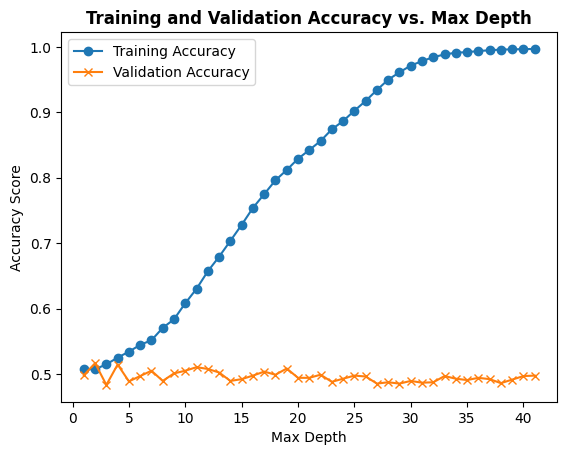

In [45]:
plt.plot(depth_hyperparams, training_acc, label="Training Accuracy", marker="o")
plt.plot(depth_hyperparams, validation_acc, label="Validation Accuracy", marker="x")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy Score")
plt.title("Training and Validation Accuracy vs. Max Depth", weight="bold")
plt.legend();

In [49]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    DecisionTreeClassifier(max_depth=best_depth, random_state=42)
)
model.fit(X_train, y_train)

test_acc = model.score(X_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.5027


In [55]:
features = model.named_steps["onehotencoder"].get_feature_names_out(X_train.columns)
importances = model.named_steps["decisiontreeclassifier"].feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.head(20)

Age Group_Early Adolescent    0.412410
Shift Duty_Morning            0.401087
Admission Month_August        0.186503
Shift Duty_Night              0.000000
Admission Month_February      0.000000
Admission Month_January       0.000000
Admission Month_March         0.000000
Admission Month_April         0.000000
Admission Month_June          0.000000
Admission Month_May           0.000000
Admission Month_July          0.000000
Admission Month_September     0.000000
Admission Month_October       0.000000
Admission Month_November      0.000000
Admission Month_December      0.000000
Admission Day_Monday          0.000000
Admission Day_Tuesday         0.000000
Admission Day_Wednesday       0.000000
Admission Day_Thursday        0.000000
Admission Day_Friday          0.000000
dtype: float64